# Đặt tên Col cho 3 files data

In [1]:
rating = r'F:\1_REL\Reinforcement-learning-for-Recommendation\Data_Movielens_1m\ml-1m\ratings.dat'
movies = r'F:\1_REL\Reinforcement-learning-for-Recommendation\Data_Movielens_1m\ml-1m\movies.dat'
users = r'F:\1_REL\Reinforcement-learning-for-Recommendation\Data_Movielens_1m\ml-1m\users.dat'

In [2]:
import pandas as pd
import numpy as np

# 1. Đọc file ratings (Quan trọng nhất)
ratings_cols = ['UserID', 'MovieID', 'Rating', 'Timestamp']
ratings = pd.read_csv(rating, sep='::', engine='python', names=ratings_cols)

# 2. Đọc file movies và users (Dùng để lấy thêm tính năng nếu cần)
movies_cols = ['MovieID', 'Title', 'Genres']
movies = pd.read_csv(movies, sep='::', engine='python', names=movies_cols, encoding='latin-1')

users_cols = ['UserID', 'Gender', 'Age', 'Occupation', 'Zip-code']
users = pd.read_csv(users, sep='::', engine='python', names=users_cols)

# Sắp xếp lịch sử đánh giá của từng user theo thời gian (Timestamp) tăng dần
ratings = ratings.sort_values(by=['UserID', 'Timestamp']).reset_index(drop=True)

In [3]:
def check_dataframe_info(df, name):
    print(f"=========================================")
    print(f"THÔNG TIN BẢNG: {name.upper()}")
    print(f"=========================================")
    # df.shape trả về một tuple: (số dòng, số cột)
    print(f"1. Số lượng mẫu (Dòng): {df.shape[0]:,}")
    print(f"2. Số lượng đặc trưng (Cột): {df.shape[1]}")
    print(f"3. Kiểu dữ liệu của từng cột:")
    # df.dtypes in ra kiểu dữ liệu của tất cả các cột
    print(df.dtypes)
    print("\n")

# Chạy hàm kiểm tra cho từng DataFrame
check_dataframe_info(ratings, "Ratings")
check_dataframe_info(users, "Users")
check_dataframe_info(movies, "Movies")

THÔNG TIN BẢNG: RATINGS
1. Số lượng mẫu (Dòng): 1,000,209
2. Số lượng đặc trưng (Cột): 4
3. Kiểu dữ liệu của từng cột:
UserID       int64
MovieID      int64
Rating       int64
Timestamp    int64
dtype: object


THÔNG TIN BẢNG: USERS
1. Số lượng mẫu (Dòng): 6,040
2. Số lượng đặc trưng (Cột): 5
3. Kiểu dữ liệu của từng cột:
UserID         int64
Gender        object
Age            int64
Occupation     int64
Zip-code      object
dtype: object


THÔNG TIN BẢNG: MOVIES
1. Số lượng mẫu (Dòng): 3,883
2. Số lượng đặc trưng (Cột): 3
3. Kiểu dữ liệu của từng cột:
MovieID     int64
Title      object
Genres     object
dtype: object




# Mã hóa ID và định nghĩa MASK/PAD

Số 0: Dành riêng làm khoảng trống ([PAD]) để bù vào các chuỗi phim bị ngắn.

Số 1 đến 3706: Dành cho các bộ phim có thật (đáp án).

Số 3707 (len + 1): Dành riêng làm Token che giấu ([MASK]), báo hiệu cho AI biết đây là "chỗ trống cần suy luận".


Tạo số 3707(blank) để nó che các phim trong chuỗi lại ví dụ

Giả sử ta chọn số 2 (phim Jumanji) làm ký hiệu để che.

-Chuỗi gốc người dùng xem: [Toy Story (1), Heat (6), Casino (16)]

-Hành động: Bạn muốn kiểm tra mô hình bằng cách giấu phim Heat (6) đi.

-Nếu bạn dán số 2 đè lên số 6: Mảng dữ liệu biến thành [1, 2, 16].

->Hậu quả: Khi máy tính đọc mảng [1, 2, 16], nó sẽ hiểu là: "À, người dùng này đã xem Toy Story, sau đó xem Jumanji, rồi xem Casino. Một chuỗi rất bình thường, chẳng có câu hỏi nào cần giải quyết ở đây cả!". Mô hình hoàn toàn không biết rằng vị trí ở giữa đã bị thay đổi và cần phải được dự đoán. Nó đã bị "đánh lừa" thành một chuỗi hợp lệ khác.

Giải pháp:

Thay vì dùng số 2, ta dùng một con số nằm ngoài danh sách phim có thật là 3707.

Chuỗi gốc: [Toy Story (1), Heat (6), Casino (16)]

Hành động: Bạn dán miếng băng keo 3707 đè lên phim Heat (6).

Kết quả: Mảng dữ liệu biến thành [1, 3707, 16].

Máy tính sẽ hiểu: "Khoan đã! Từ điển phim chỉ có từ 1 đến 3706 thôi. Số 3707 này là một ký hiệu đặc biệt báo hiệu chỗ trống (Fill-in-the-blank). Nhiệm vụ của mình là phải nhìn vào phim số 1 và phim số 16 ở hai bên, để suy luận xem cái phim nằm dưới lớp băng keo 3707 kia thực chất là phim số mấy trong tập từ 1 đến 3706!"

In [4]:
# Tạo từ điển mã hóa MovieID thành các số nguyên liên tục bắt đầu từ 1
raw_movie_ids = sorted(ratings['MovieID'].unique())
movie2id = {raw_id: i + 1 for i, raw_id in enumerate(raw_movie_ids)}

# Số lượng phim thực tế
NUM_ITEMS = len(movie2id)  
id2movie      = {v: k for k, v in movie2id.items()}

# Áp dụng mã hóa vào bảng ratings
ratings['Movie_Encoded'] = ratings['MovieID'].map(movie2id)

# Gom nhóm thành chuỗi lịch sử (Sequence Generation)

Gom các đánh giá rời rạc thành các chuỗi hành vi (sequences) của từng người dùng

In [5]:
user_sequences = ratings.groupby('UserID')['Movie_Encoded'].apply(list).to_dict()

**Output mẫu**

{

    1: [32, 15, 114, 5, ...], # Lịch sử xem của UserID 1
    
    2: [18, 5, 233, ...],     # Lịch sử xem của UserID 2
    ...
}

In [6]:
print(user_sequences[1])  # In ra lịch sử đánh giá của user có ID = 1 sau khi mã hóa

[2970, 1179, 1575, 958, 2148, 1659, 3178, 2600, 1118, 1105, 690, 254, 859, 594, 2489, 1782, 1849, 2890, 878, 971, 1783, 1839, 145, 964, 1026, 854, 1196, 2593, 2558, 1155, 640, 2711, 518, 2899, 2587, 2129, 965, 1108, 581, 2206, 1422, 514, 582, 2484, 709, 575, 1, 2163, 2103, 741, 1440, 1728, 48]


In [7]:
print(user_sequences[2]) 

[1109, 1121, 1128, 2513, 1202, 2736, 1136, 1105, 310, 2817, 2652, 1124, 1766, 1118, 580, 2880, 3236, 1694, 502, 1019, 2308, 2822, 107, 1887, 2932, 1156, 2890, 1260, 1107, 1778, 1774, 860, 1657, 1013, 1783, 3239, 3413, 3494, 1168, 1775, 1619, 2524, 1789, 1032, 842, 3220, 3342, 2646, 3108, 2854, 259, 2121, 577, 1162, 2857, 1153, 3458, 1776, 1154, 2047, 3437, 921, 2014, 2079, 1338, 3032, 627, 229, 1025, 1048, 485, 1155, 3648, 1415, 1100, 2204, 2167, 2129, 347, 2893, 1174, 3567, 576, 1849, 2375, 444, 2709, 1479, 467, 158, 371, 3187, 3033, 1307, 21, 340, 1407, 2161, 1827, 2087, 1272, 628, 2235, 1624, 1274, 1429, 2297, 1287, 738, 2675, 2892, 359, 1632, 160, 446, 429, 1467, 2427, 1554, 3034, 703, 1823, 1946, 284, 93, 1551, 421, 1421, 1738]


# Chia dữ liệu và Xử lý độ dài chuỗi

In [8]:
# ============================================================
# 4. CHIA TRAIN / VAL / TEST  (Leave-One-Out)
#
#   train : tất cả trừ 2 item cuối  →  sliding-window augmentation
#   val   : item áp chót  (dùng để chọn hyperparameter nếu cần)
#   test  : item cuối cùng
#
#   Lọc user có ít nhất 3 item (cần ít nhất 1 train + 1 val + 1 test)
# ============================================================
MAX_LEN    = 200
MIN_SEQ    = 3      # bỏ user có < 3 item

train_seqs = []   # list of list[int]  — chuỗi con dùng để train
val_seqs   = []   # (input_seq, target_item)
test_seqs  = []   # (input_seq, target_item)

for user, seq in user_sequences.items():
    if len(seq) < MIN_SEQ:
        continue

    # Test: item cuối
    test_target = seq[-1]
    test_input  = seq[:-1]

    # Val: item áp chót
    val_target  = seq[-2]
    val_input   = seq[:-2]

    # Train: tất cả trừ 2 item cuối  → sliding window
    train_raw = seq[:-2]
    for end in range(2, len(train_raw) + 1):      # chuỗi con độ dài 2..len
        sub = train_raw[:end]
        # RIGHT-PADDING với 0  (giống BERT4RecDataset trong file model)
        if len(sub) > MAX_LEN:
            sub = sub[-MAX_LEN:]
        train_seqs.append(sub)

    val_seqs.append((val_input,  val_target))
    test_seqs.append((test_input, test_target))

print(f"Train sequences (sau sliding window) : {len(train_seqs):,}")
print(f"Val  users                           : {len(val_seqs):,}")
print(f"Test users                           : {len(test_seqs):,}")

Train sequences (sau sliding window) : 982,089
Val  users                           : 6,040
Test users                           : 6,040


# BERT4REC

introduction BERT4REC with RecBole: https://recbole.io/docs/user_guide/model/sequential/bert4rec.html#introduction

**Ở code model này**
Không kéo thằng của RecBole về, chỉ code file Bert4Rec dựa trên ref của github: 

recbole/model/sequential_recommender/bert4rec.py

In [9]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"  # BẮT BUỘC đặt trước mọi thứ

import numpy as np
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader
from Bert4Rec_model import BERT4Rec
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [10]:
# ============================================================
# 5. BERT4REC DATASET & DATALOADER
#    Dùng BERT4RecDataset từ file model — masking ở __getitem__,
#    KHÔNG phải trong model hay training loop.
# ============================================================
from Bert4Rec_model import BERT4Rec, BERT4RecDataset

MASK_RATIO = 0.2
BATCH_SIZE = 256

train_dataset = BERT4RecDataset(
    sequences   = train_seqs,
    n_items     = NUM_ITEMS,
    max_seq_len = MAX_LEN,
    mask_ratio  = MASK_RATIO,
    # mask_token tự động = n_items = 3706
)

# num_workers=4: DataLoader tạo mask song song trong các worker process
# → masking không block GPU training  (đây là fix chính so với code cũ)
train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = 4,        # song song hoá masking
    pin_memory  = True,     # tăng tốc chuyển tensor lên GPU
)

print(f"Số batch mỗi epoch : {len(train_loader)}")
print(f"mask_item_length   : {train_dataset.mask_item_length}  "
      f"(= int({MASK_RATIO} * {MAX_LEN}))")

Số batch mỗi epoch : 3837
mask_item_length   : 40  (= int(0.2 * 200))


In [11]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Device : {device}")

Device : cuda


In [12]:
# ============================================================
# 6. KHỞI TẠO MODEL
# ============================================================
import math
from torch.optim.lr_scheduler import LambdaLR



# BATCH_SIZE    = 256
WARMUP_EPOCHS = 10
TOTAL_EPOCHS  = 200 

max_item = max(item for seq in train_seqs for item in seq)  # = 3706


model = BERT4Rec(
    n_items             = max_item + 1,    # = 3707: CE cần cover index 1..3706
    max_seq_length      = MAX_LEN,      # 50
    hidden_size         = 64,
    n_layers            = 2,
    n_heads             = 2,
    inner_size          = 256,
    hidden_dropout_prob = 0.2,
    attn_dropout_prob   = 0.2,
    hidden_act          = "gelu",
    mask_ratio          = MASK_RATIO,
    loss_type           = "CE",
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return epoch / max(1, WARMUP_EPOCHS)
    progress = (epoch - WARMUP_EPOCHS) / max(1, TOTAL_EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = LambdaLR(optimizer, lr_lambda)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"n_items          : {model.n_items}")          # 3706
print(f"mask_token       : {model.mask_token}")       # 3706
print(f"embedding size   : {tuple(model.item_embedding.weight.shape)}")  # (3707, 64)
print(f"output_bias size : {model.output_bias.shape[0]}")                # 3706
print(f"Trainable params : {n_params:,}")

n_items          : 3707
mask_token       : 3707
embedding size   : (3708, 64)
output_bias size : 3707
Trainable params : 358,203


In [13]:
import math
from torch.utils.data import TensorDataset, DataLoader

def build_test_tensors(seqs, n_items, max_len):
    MASK_TOKEN = n_items  # khớp model.mask_token
    X, Y = [], []
    for input_seq, target in seqs:
        seq_with_mask = input_seq + [MASK_TOKEN]
        if len(seq_with_mask) > max_len:
            seq_with_mask = seq_with_mask[-max_len:]
        pad_len = max_len - len(seq_with_mask)
        padded  = [0] * pad_len + seq_with_mask
        X.append(padded)
        Y.append(target)
    return (torch.tensor(X, dtype=torch.long),
            torch.tensor(Y, dtype=torch.long))

val_X,  val_Y  = build_test_tensors(val_seqs,  model.n_items, MAX_LEN)
test_X, test_Y = build_test_tensors(test_seqs, model.n_items, MAX_LEN)

val_loader = DataLoader(
    TensorDataset(val_X, val_Y),
    batch_size=256, shuffle=False
)
test_loader = DataLoader(
    TensorDataset(test_X, test_Y),
    batch_size=256, shuffle=False
)

print(f"Val  users : {len(val_Y):,}")
print(f"Test users : {len(test_Y):,}")

Val  users : 6,040
Test users : 6,040


In [22]:
from collections import Counter
import numpy as np
import random

# ── Tính popularity distribution từ train_seqs ──────────────
# Chạy 1 lần trước khi gọi evaluate
all_items_flat   = [item for seq in train_seqs for item in seq]
item_counts      = Counter(all_items_flat)
pop_items        = np.array(list(item_counts.keys()),   dtype=np.int64)
pop_counts       = np.array(list(item_counts.values()), dtype=np.float32)
popularity_probs = pop_counts / pop_counts.sum()

@torch.no_grad()
def evaluate(model, loader, device, ks=(1, 5, 10), num_neg=99):
    model.eval()
    metrics = {f"HR@{k}": 0.0 for k in ks}
    metrics.update({f"NDCG@{k}": 0.0 for k in ks})
    metrics["MRR"] = 0.0
    total = 0

    for masked_seq, targets in loader:
        masked_seq = masked_seq.to(device)
        targets    = targets.to(device)

        seq_out    = model.forward(masked_seq)
        last_out   = seq_out[:, -1, :]                             # [B, H]
        item_emb   = model.item_embedding.weight[: model.n_items]  # [n_items, H]
        all_logits = torch.matmul(last_out, item_emb.transpose(0, 1)) \
                     + model.output_bias                            # [B, n_items]

        for i in range(targets.size(0)):
            target = targets[i].item()

            # Sample 99 negatives theo popularity distribution (đúng paper gốc)
            negs = []
            while len(negs) < num_neg:
                neg = int(np.random.choice(pop_items, p=popularity_probs))
                if neg != target and neg not in negs:
                    negs.append(neg)

            # 100 candidates: index 0 = target, index 1..99 = negatives
            candidates  = [target] + negs
            cand_tensor = torch.tensor(candidates, dtype=torch.long, device=device)
            scores      = all_logits[i][cand_tensor]               # [100]

            # Rank của target (index 0) trong 100 candidates
            _, indices = torch.sort(scores, descending=True)
            rank = (indices == 0).nonzero(as_tuple=True)[0].item() + 1

            metrics["MRR"] += 1.0 / rank
            for k in ks:
                if rank <= k:
                    metrics[f"HR@{k}"]   += 1.0
                    metrics[f"NDCG@{k}"] += 1.0 / math.log2(rank + 1)
            total += 1

    if total > 0:
        for key in metrics:
            metrics[key] /= total

    model.train()
    return metrics, total

In [15]:
EPOCHS          = 400
MODEL_SAVE_PATH = "saved_models/bert4rec_best.pth"
PATIENCE        = 5    # 10 lần eval không cải thiện = dừng
EVAL_EVERY      = 10

patience_counter = 0
best_val_hr10    = 0.0
best_loss        = float("inf")
history_loss     = []
history_acc      = []

print("-" * 60) 
print(f"BẮT ĐẦU HUẤN LUYỆN — {EPOCHS} epochs  |  device: {device}")
print(f"Early Stopping: PATIENCE = {PATIENCE} lần eval (mỗi {EVAL_EVERY} epoch)")
print("-" * 60)

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0; total_correct = 0; total_masked = 0

    pbar = tqdm(total=len(train_loader),
                desc=f"Epoch {epoch+1:03d}/{EPOCHS}",
                leave=True, dynamic_ncols=True)

    for batch in train_loader:
        masked_item_seq = batch["masked_item_seq"].to(device)
        pos_items       = batch["pos_items"].to(device)
        neg_items       = batch["neg_items"].to(device)
        masked_index    = batch["masked_index"].to(device)

        optimizer.zero_grad()
        loss = model.calculate_loss(masked_item_seq, pos_items, neg_items, masked_index)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clip
        optimizer.step()
        total_loss += loss.item()

        with torch.no_grad():
            seq_out  = model.forward(masked_item_seq)
            pred_map = model.multi_hot_embed(
                masked_index, masked_item_seq.size(-1)
            ).view(masked_index.size(0), masked_index.size(1), -1)
            gathered = torch.bmm(pred_map, seq_out)
            emb      = model.item_embedding.weight[: model.n_items]
            logits   = torch.matmul(gathered, emb.transpose(0, 1)) + model.output_bias
            preds    = logits.argmax(dim=-1)
            valid    = (masked_index > 0)
            total_correct += ((preds == pos_items) & valid).sum().item()
            total_masked  += valid.sum().item()

        pbar.set_postfix({"loss": f"{loss.item():.4f}"})
        pbar.update(1)

    scheduler.step()
    print(f"LR hiện tại: {scheduler.get_last_lr()[0]:.6f}")

    avg_loss = total_loss / len(train_loader)
    avg_acc  = total_correct / total_masked if total_masked > 0 else 0.0
    history_loss.append(avg_loss)
    history_acc.append(avg_acc * 100)

    if avg_loss < best_loss:
        best_loss = avg_loss   # chỉ để theo dõi, không save ở đây

    pbar.set_postfix_str(f"Loss: {avg_loss:.4f} | Acc: {avg_acc*100:.2f}%")
    pbar.close()

    # ── Validation mỗi EVAL_EVERY epoch ──────────────────────
    if (epoch + 1) % EVAL_EVERY == 0:
        val_metrics, _ = evaluate(model, val_loader, device, ks=(10,))
        val_hr10 = val_metrics["HR@10"]
        print(f"  → [Val epoch {epoch+1}] HR@10: {val_hr10:.4f}  (best: {best_val_hr10:.4f})")

        if val_hr10 > best_val_hr10:
            best_val_hr10    = val_hr10
            patience_counter = 0
            torch.save(model.state_dict(), MODEL_SAVE_PATH)
            print(f"  → Saved! Val HR@10 = {val_hr10:.4f}")
        else:
            patience_counter += 1
            print(f"  → Không cải thiện [{patience_counter}/{PATIENCE}]")
            if patience_counter >= PATIENCE:
                print("!" * 60)
                print(f"EARLY STOPPING tại epoch {epoch+1} | Best Val HR@10: {best_val_hr10:.4f}")
                print("!" * 60)
                break
    # ─────────────────────────────────────────────────────────

print("-" * 60)
print(f"HOÀN THÀNH! Best Loss: {best_loss:.4f} | Best Val HR@10: {best_val_hr10:.4f}")
print(f"Model: {MODEL_SAVE_PATH} | Epochs: {epoch+1}")
print("-" * 60)

------------------------------------------------------------
BẮT ĐẦU HUẤN LUYỆN — 400 epochs  |  device: cuda
Early Stopping: PATIENCE = 5 lần eval (mỗi 10 epoch)
------------------------------------------------------------


Epoch 001/400: 100%|██████████| 3837/3837 [06:31<00:00,  9.79it/s, Loss: 8.2301 | Acc: 0.03%]


LR hiện tại: 0.000100


Epoch 002/400: 100%|██████████| 3837/3837 [06:19<00:00, 10.10it/s, Loss: 7.0436 | Acc: 0.91%]


LR hiện tại: 0.000200


...

Epoch 099/400: 100%|██████████| 3837/3837 [06:35<00:00,  9.70it/s, Loss: 5.3276 | Acc: 3.71%]


LR hiện tại: 0.000550


Epoch 100/400: 100%|██████████| 3837/3837 [06:28<00:00,  9.87it/s, Loss: 5.3274 | Acc: 3.71%]

LR hiện tại: 0.000541


  → [Val epoch 100] HR@10: 0.6935  (best: 0.6942)
  → Không cải thiện [5/5]
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
EARLY STOPPING tại epoch 100 | Best Val HR@10: 0.6942
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
------------------------------------------------------------
HOÀN THÀNH! Best Loss: 5.3274 | Best Val HR@10: 0.6942
Model: saved_models/bert4rec_best.pth | Epochs: 100
------------------------------------------------------------


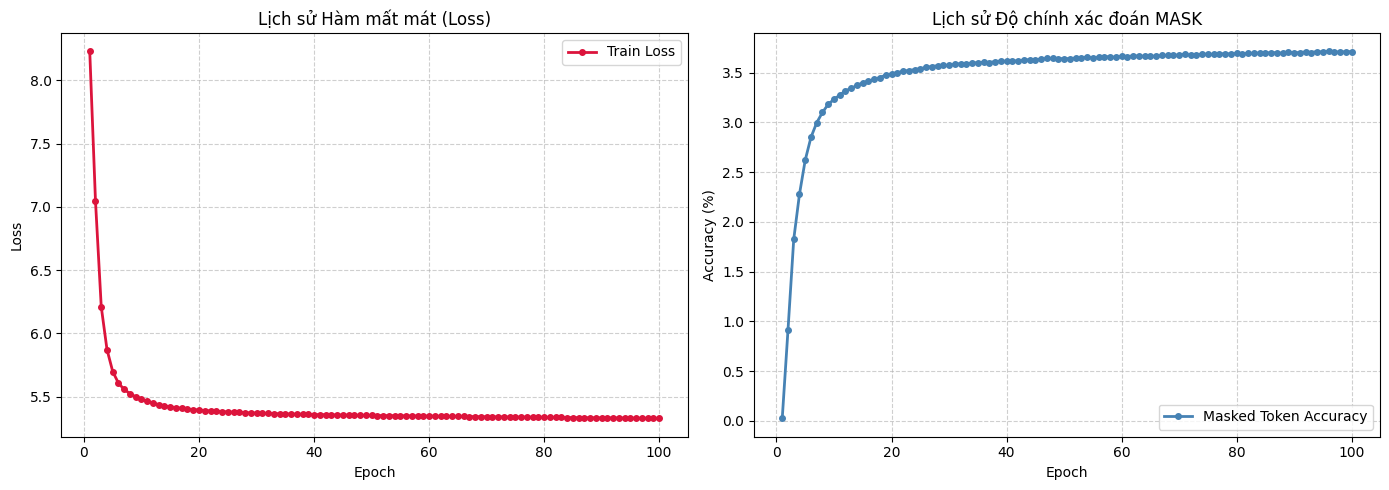

📊 Biểu đồ lưu tại: saved_models/training_history.png


In [16]:
# ============================================================
# 8. VẼ BIỂU ĐỒ TRAINING
# ============================================================

import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epoch_range = range(1, len(history_loss) + 1)

ax1.plot(epoch_range, history_loss, marker="o", color="crimson",
         linewidth=2, markersize=4, label="Train Loss")
ax1.set_title("Lịch sử Hàm mất mát (Loss)")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.grid(True, linestyle="--", alpha=0.6); ax1.legend()

ax2.plot(epoch_range, history_acc, marker="o", color="steelblue",
         linewidth=2, markersize=4, label="Masked Token Accuracy")
ax2.set_title("Lịch sử Độ chính xác đoán MASK")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
ax2.grid(True, linestyle="--", alpha=0.6); ax2.legend()

plt.tight_layout()
CHART_PATH = "saved_models/training_history.png"
plt.savefig(CHART_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"📊 Biểu đồ lưu tại: {CHART_PATH}")

# Test

In [17]:
# ============================================================
# 9. TẠO TEST LOADER  (Leave-One-Out, chuẩn RecBole)
#
#   Mỗi user:
#     input  = toàn bộ lịch sử trừ item cuối  +  MASK_TOKEN ở cuối
#     target = item cuối (ground truth)
#
#   Padding: LEFT-PAD với 0 để MASK luôn ở vị trí -1  (index L-1)
#   → model gọi forward(masked_seq) rồi lấy output[:, -1, :]
# ============================================================
def build_test_tensors(seqs, n_items, max_len):
    """
    seqs : list of (input_seq: list[int], target_item: int)
    Trả về (X_tensor [N, max_len], y_tensor [N])
    """
    MASK_TOKEN = n_items  # khớp model.mask_token
    X, Y = [], []
    for input_seq, target in seqs:
        # Chèn MASK ở cuối phần thật
        seq_with_mask = input_seq + [MASK_TOKEN]
        # Cắt nếu dài hơn max_len
        if len(seq_with_mask) > max_len:
            seq_with_mask = seq_with_mask[-max_len:]
        # Left-pad
        pad_len = max_len - len(seq_with_mask)
        padded  = [0] * pad_len + seq_with_mask
        X.append(padded)
        Y.append(target)
    return (torch.tensor(X, dtype=torch.long),
            torch.tensor(Y, dtype=torch.long))

test_X, test_Y = build_test_tensors(test_seqs, NUM_ITEMS, MAX_LEN)
val_X,  val_Y  = build_test_tensors(val_seqs,  NUM_ITEMS, MAX_LEN)

from torch.utils.data import TensorDataset

test_loader = DataLoader(
    TensorDataset(test_X, test_Y),
    batch_size=256, shuffle=False
)
val_loader = DataLoader(
    TensorDataset(val_X, val_Y),
    batch_size=256, shuffle=False
)

print(f"Test users : {len(test_Y):,}")
print(f"Val  users : {len(val_Y):,}")

Test users : 6,040
Val  users : 6,040


In [18]:
# ============================================================
# 10. HÀM ĐÁNH GIÁ  — HR@K, NDCG@K, MRR
#     Input:  masked_seq [B, L]  — MASK ở vị trí -1
#     Output: logit lấy tại vị trí cuối cùng [:, -1, :]
# ============================================================
@torch.no_grad()
def evaluate(model, loader, device, ks=(1, 5, 10)):
    model.eval()
    metrics  = {f"HR@{k}": 0.0 for k in ks}
    metrics.update({f"NDCG@{k}": 0.0 for k in ks})
    metrics["MRR"] = 0.0
    total = 0

    for masked_seq, targets in loader:
        masked_seq = masked_seq.to(device)   # [B, L]
        targets    = targets.to(device)      # [B]

        # Forward — lấy output tại vị trí cuối (vị trí MASK)
        seq_out = model.forward(masked_seq)  # [B, L, H]
        last_out = seq_out[:, -1, :]         # [B, H]

        # Score toàn bộ item thật
        item_emb = model.item_embedding.weight[: model.n_items]  # [n_items, H]
        logits   = torch.matmul(last_out, item_emb.transpose(0, 1)) \
                   + model.output_bias                            # [B, n_items]

        max_k   = max(ks)
        _, topk = torch.topk(logits, max_k, dim=-1)  # [B, max_k]

        for i in range(targets.size(0)):
            target = targets[i].item()
            preds  = topk[i].tolist()

            if target in preds:
                rank = preds.index(target) + 1  # 1-based
                metrics["MRR"] += 1.0 / rank
                for k in ks:
                    if rank <= k:
                        metrics[f"HR@{k}"]   += 1.0
                        metrics[f"NDCG@{k}"] += 1.0 / math.log2(rank + 1)
            total += 1

    if total > 0:
        for key in metrics:
            metrics[key] /= total

    return metrics, total

In [23]:
# ============================================================
# 11. THỰC THI ĐÁNH GIÁ
# ============================================================
# Load best checkpoint
if os.path.exists(MODEL_SAVE_PATH):
    model.load_state_dict(
        torch.load(MODEL_SAVE_PATH, map_location=device, weights_only=True)
    )
    print(f"✅ Loaded: {MODEL_SAVE_PATH}")

print("\n" + "=" * 50)
print("🎯 KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST")
print("=" * 50)

test_metrics, n_test = evaluate(model, test_loader, device,
                                ks=(1, 5, 10), num_neg=99)  # ← thêm num_neg=99
for k, v in test_metrics.items():
    print(f"  {k:<10}: {v:.4f}")
print(f"  (Tổng {n_test:,} users)")
print("-" * 50)

print("\n📊 KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP VAL")
print("-" * 50)
val_metrics, n_val = evaluate(model, val_loader, device,
                               ks=(1, 5, 10), num_neg=99)  # ← thêm num_neg=99
for k, v in val_metrics.items():
    print(f"  {k:<10}: {v:.4f}")
print(f"  (Tổng {n_val:,} users)")
print("-" * 50)

✅ Loaded: saved_models/bert4rec_best.pth

🎯 KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST
  HR@1      : 0.2101
  HR@5      : 0.5421
  HR@10     : 0.6609
  NDCG@1    : 0.2101
  NDCG@5    : 0.3844
  NDCG@10   : 0.4232
  MRR       : 0.3614
  (Tổng 6,040 users)
--------------------------------------------------

📊 KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP VAL
--------------------------------------------------
  HR@1      : 0.2227
  HR@5      : 0.5685
  HR@10     : 0.6969
  NDCG@1    : 0.2227
  NDCG@5    : 0.4032
  NDCG@10   : 0.4447
  MRR       : 0.3777
  (Tổng 6,040 users)
--------------------------------------------------
